# GAM trên transformed feature space

> Theo gợi ý của mentor tuần 2. Đây là mục cuối còn lại của cấu phần (ii).

## Vấn đề cần giải

GAM là mô hình **cộng dồn**: `y = b₀ + f₁(x₁) + f₂(x₂) + ...`. Nó **không thể** học tương tác —
không diễn đạt được *"cầu cao **và** đang giờ cao điểm thì hệ số nhân vọt lên gấp bội"*.

Hậu quả đo được ở `evaluation/08_truc_quan_GAM.ipynb`:

| Nhánh | GAM vs boosting tree | Cây học lại được từ phần dư GAM |
|---|---:|---:|
| Giá cơ bản | +0,5% (ngang) | R² = 0,018 → GAM đã vắt kiệt |
| **Hệ số nhân** | **+30,5%** | **R² = 0,562 → còn cấu trúc bỏ sót** |

Và ở `train/04` đã loại trừ giả thuyết *"thua vì `λ` chưa tối ưu"* — gridsearch trên lưới 4 bậc
độ lớn không cải thiện gì.

⇒ Khoảng cách 30% là **cấu trúc**: thiếu tương tác. Notebook này thử đóng nó.

## Ba hướng thử

| # | Cách | Ý tưởng |
|---|---|---|
| **A** | GAM gốc | Mốc so sánh |
| **B** | **Feature biến đổi thủ công** | Tự tạo sẵn biến mang tương tác: tỷ số cầu/cung, tích, sin/cos giờ |
| **C** | **Tensor product `te()`** | Để GAM học mặt cong 2 chiều `f(x₁, x₂)` — cách chính thống của GAM |

Hướng C giữ được ưu điểm giải thích được (vẽ ra được mặt cong), khác hẳn hộp đen của cây.

## Nguyên tắc so sánh công bằng

Cả 3 cấu hình train trên **cùng một mẫu con** (`N_TRAIN` dòng) và đánh giá trên **cùng tập test
đầy đủ**. Con số tuyệt đối sẽ khác model production (train trên toàn bộ), nhưng **so sánh giữa các
cấu hình là hợp lệ** — đó mới là thứ cần biết.

In [1]:
import warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pygam import LinearGAM, s, f, te
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
M_NUM = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
         "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag",
         "latest_observed_multiplier", "gio_vn", "actual_observation_age_minutes"]

N_TRAIN = 500_000       # mau con dung CHUNG cho moi cau hinh -> so sanh cong bang
N_SPL = 12
LAM = 0.6
THANG_TRAIN = "2026-03"

COLS = list(dict.fromkeys(CAT + M_NUM + ["target_shown_multiplier",
                                         "evaluation_month", "split"]))
df = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=COLS)
enc = OrdinalEncoder(dtype=np.int64, handle_unknown="use_encoded_value", unknown_value=-1)
df[CAT] = enc.fit_transform(df[CAT].astype(str))

tr_full = df[(df.split == "train") & (df.evaluation_month == THANG_TRAIN)]
te_full = df[(df.split == "test") & (df.evaluation_month == THANG_TRAIN)].copy()
rng = np.random.default_rng(42)
tr = tr_full.iloc[rng.choice(len(tr_full), min(N_TRAIN, len(tr_full)), replace=False)].copy()

print(f"Train (mau con) : {len(tr):,}  | thang {THANG_TRAIN}")
print(f"Test (day du)   : {len(te_full):,}")
print(f"Target          : log(target_shown_multiplier)")

Train (mau con) : 500,000  | thang 2026-03
Test (day du)   : 314,368
Target          : log(target_shown_multiplier)


## 1. Tương tác nằm ở cặp feature nào?

Trước khi thêm term, phải biết **thêm cho cặp nào**. Cách đo: lấy phần dư của GAM cộng dồn, rồi
với mỗi cặp `(x₁, x₂)` xem chia lưới 2 chiều giải thích thêm được bao nhiêu **so với** chỉ dùng
hai hiệu ứng 1 chiều.

$$\text{cường độ tương tác} = 1 - \frac{\mathrm{Var}[\,r - \bar r_{2D}\,]}{\mathrm{Var}[\,r - \bar r_{1} - \bar r_{2}\,]}$$

Vì phần dư đã bị GAM khử hết hiệu ứng 1 chiều, mọi cấu trúc 2 chiều còn lại **chính là tương tác**.

In [2]:
FE_A = M_NUM + CAT


def terms_congdon(n_num, n_cat):
    t = s(0, n_splines=N_SPL)
    for i in range(1, n_num):
        t += s(i, n_splines=N_SPL)
    for i in range(n_num, n_num + n_cat):
        t += f(i)
    return t


def fit_gam(terms, feats, tr_, te_, ten):
    t0 = time.time()
    X = tr_[feats].values.astype(float)
    y = np.log(np.clip(tr_.target_shown_multiplier.values, 1e-6, None))
    g = LinearGAM(terms, lam=LAM, max_iter=25).fit(X, y)
    p = np.exp(g.predict(te_[feats].values.astype(float)))
    t_ = te_.target_shown_multiplier.values
    mae = np.abs(p - t_).mean()
    r2 = 1 - ((p-t_)**2).sum()/((t_-t_.mean())**2).sum()
    print(f"  [{ten:34s}] MAE {mae:.5f} | R2 {r2:.4f} | {len(terms)-1:2d} term | "
          f"{time.time()-t0:5.0f}s")
    return dict(ten=ten, gam=g, mae=mae, r2=r2, pred=p, n_term=len(terms)-1)


print("A. GAM CONG DON THUAN (moc so sanh)")
A = fit_gam(terms_congdon(len(M_NUM), len(CAT)), FE_A, tr, te_full, "A. Cộng dồn thuần")

# --- Do cuong do tuong tac tren PHAN DU ---
du_tr = (np.log(np.clip(tr.target_shown_multiplier.values, 1e-6, None))
         - A["gam"].predict(tr[FE_A].values.astype(float)))


def cuong_do(du, x1, x2, nbin=8):
    b1 = pd.qcut(pd.Series(x1), nbin, labels=False, duplicates="drop")
    b2 = pd.qcut(pd.Series(x2), nbin, labels=False, duplicates="drop")
    d = pd.DataFrame({"du": du, "b1": b1.values, "b2": b2.values}).dropna()
    m = d.du.mean()
    r1 = d.du - d.groupby("b1").du.transform("mean") - \
        d.groupby("b2").du.transform("mean") + m
    r2_ = d.du - d.groupby(["b1", "b2"]).du.transform("mean")
    return max(0.0, 1 - r2_.var()/r1.var())


rows = []
for i in range(len(M_NUM)):
    for j in range(i+1, len(M_NUM)):
        a, b = M_NUM[i], M_NUM[j]
        if tr[a].nunique() < 8 or tr[b].nunique() < 8:
            continue
        rows.append({"f1": a, "f2": b, "cuong_do": cuong_do(du_tr, tr[a].values, tr[b].values)})
CD = pd.DataFrame(rows).sort_values("cuong_do", ascending=False).reset_index(drop=True)
print("\nCUONG DO TUONG TAC tren phan du GAM (top 8):")
display(CD.head(8).round(4))

A. GAM CONG DON THUAN (moc so sanh)


  [A. Cộng dồn thuần                 ] MAE 0.03090 | R2 0.9399 | 10 term |    18s



CUONG DO TUONG TAC tren phan du GAM (top 8):


,f1,f2,cuong_do
0,pricing_market_imbalance_5m_lag,latest_observed_multiplier,0.1064
1,pricing_supply_index_5m_lag,latest_observed_multiplier,0.0432
2,latest_observed_multiplier,gio_vn,0.0303
3,pricing_demand_index_5m_lag,latest_observed_multiplier,0.0293
4,gio_vn,actual_observation_age_minutes,0.0212
5,pricing_market_imbalance_5m_lag,actual_observation_age_minutes,0.0158
6,pricing_supply_index_5m_lag,gio_vn,0.0137
7,pricing_market_imbalance_5m_lag,gio_vn,0.0128


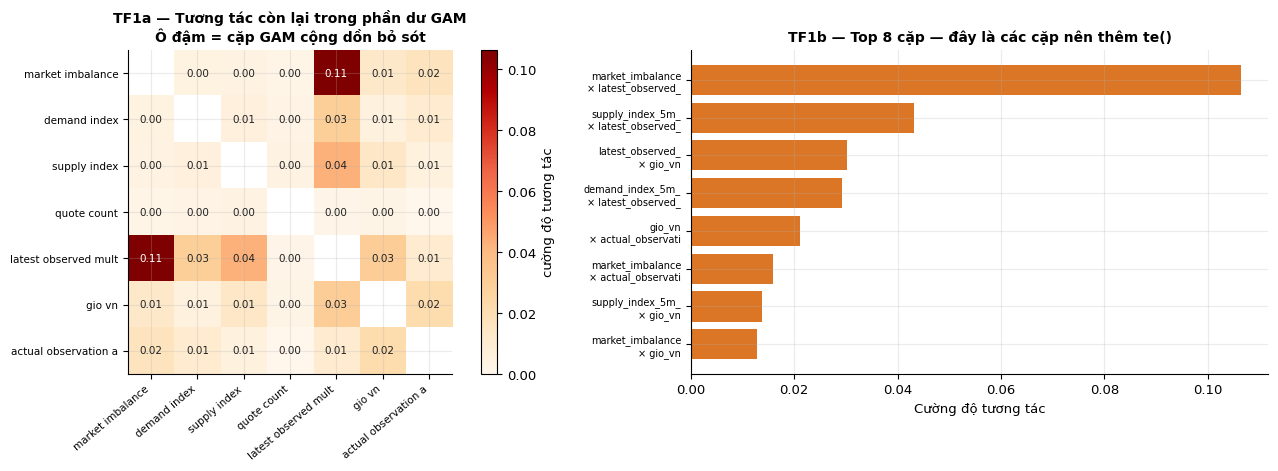

In [3]:
# ═════════ HINH TF1 — ban do cuong do tuong tac ═════════
M = pd.DataFrame(np.nan, index=M_NUM, columns=M_NUM)
for _, r in CD.iterrows():
    M.loc[r.f1, r.f2] = r.cuong_do
    M.loc[r.f2, r.f1] = r.cuong_do

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
im = ax[0].imshow(M.values.astype(float), cmap="OrRd", vmin=0)
ten_ngan = [c.replace("pricing_", "").replace("_5m_lag", "").replace("_", " ")[:20]
            for c in M_NUM]
ax[0].set_xticks(range(len(M_NUM))); ax[0].set_xticklabels(ten_ngan, rotation=40,
                                                           ha="right", fontsize=7.5)
ax[0].set_yticks(range(len(M_NUM))); ax[0].set_yticklabels(ten_ngan, fontsize=7.5)
for i in range(len(M_NUM)):
    for j in range(len(M_NUM)):
        v = M.values[i, j]
        if not np.isnan(v):
            ax[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                       color="white" if v > np.nanmax(M.values)*.6 else INK)
plt.colorbar(im, ax=ax[0], label="cường độ tương tác")
ax[0].set_title("TF1a — Tương tác còn lại trong phần dư GAM\nÔ đậm = cặp GAM cộng dồn bỏ sót",
                fontweight="bold", fontsize=10)

top = CD.head(8)
ax[1].barh(range(len(top)), top.cuong_do, color=RED, alpha=.85)
ax[1].set_yticks(range(len(top)))
ax[1].set_yticklabels([f"{r.f1.replace('pricing_','')[:16]}\n× {r.f2.replace('pricing_','')[:16]}"
                       for _, r in top.iterrows()], fontsize=7)
ax[1].invert_yaxis()
ax[1].set_xlabel("Cường độ tương tác")
ax[1].set_title("TF1b — Top 8 cặp — đây là các cặp nên thêm te()",
                fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(HINH / "TF1_cuong_do_tuong_tac.png"); plt.show()

## 2. Hướng B — feature biến đổi thủ công

Tự tạo sẵn biến mang sẵn tương tác, rồi vẫn dùng GAM cộng dồn thuần. Các biến chọn theo **lập luận
kinh tế**, không phải thử mò:

| Biến mới | Công thức | Vì sao |
|---|---|---|
| `ty_le_cau_cung` | `demand / supply` | Tỷ số là dạng tương tác cơ bản nhất của surge |
| `log_ty_le` | `log(demand / supply)` | Surge thường phản ứng theo log |
| `cau_moi_xe` | `quote_count / supply` | Áp lực thực trên mỗi tài xế |
| `sin_gio`, `cos_gio` | `sin/cos(2π·giờ/24)` | Giờ có **tính chu kỳ** — 23h và 0h phải gần nhau |
| `imb_x_caodiem` | `imbalance × 1[7≤giờ≤9 hoặc 17≤giờ≤19]` | Mất cân bằng lúc cao điểm khác lúc thường |

In [4]:
def them_bien(d):
    d = d.copy()
    sup = d.pricing_supply_index_5m_lag.clip(lower=1e-3)
    d["ty_le_cau_cung"] = d.pricing_demand_index_5m_lag / sup
    d["log_ty_le"] = np.log(d.ty_le_cau_cung.clip(lower=1e-6))
    d["cau_moi_xe"] = d.pricing_quote_count_5m_lag / sup
    d["sin_gio"] = np.sin(2*np.pi*d.gio_vn/24)
    d["cos_gio"] = np.cos(2*np.pi*d.gio_vn/24)
    cao_diem = (d.gio_vn.between(7, 9) | d.gio_vn.between(17, 19)).astype(float)
    d["imb_x_caodiem"] = d.pricing_market_imbalance_5m_lag * cao_diem
    d["mult_x_imb"] = d.latest_observed_multiplier * d.pricing_market_imbalance_5m_lag
    return d


BIEN_MOI = ["ty_le_cau_cung", "log_ty_le", "cau_moi_xe", "sin_gio", "cos_gio",
            "imb_x_caodiem", "mult_x_imb"]
tr_b = them_bien(tr); te_b = them_bien(te_full)
FE_B = M_NUM + BIEN_MOI + CAT

print("B. GAM + FEATURE BIEN DOI THU CONG")
print(f"   Them {len(BIEN_MOI)} bien -> {len(FE_B)} feature")
B = fit_gam(terms_congdon(len(M_NUM)+len(BIEN_MOI), len(CAT)), FE_B, tr_b, te_b,
            "B. + feature biến đổi")

B. GAM + FEATURE BIEN DOI THU CONG
   Them 7 bien -> 18 feature


  [B. + feature biến đổi             ] MAE 0.02840 | R2 0.9461 | 17 term |    38s


## 3. Hướng C — tensor product `te()`

`te(i, j)` cho GAM học một **mặt cong 2 chiều** `f(xᵢ, xⱼ)` thay vì hai đường cong tách rời. Đây
là cách chính thống của GAM để mô hình tương tác — và **vẫn vẽ ra xem được**, khác hộp đen của cây.

Thêm `te()` cho các cặp mạnh nhất tìm được ở Phần 1. Dùng ít spline hơn cho tensor term
(`n_splines=6` mỗi chiều = 36 hàm cơ sở) để không bùng nổ số tham số.

In [5]:
TOP_K = 3
cap_top = [(r.f1, r.f2) for _, r in CD.head(TOP_K).iterrows()]
print("Cac cap them te():")
for a, b in cap_top:
    print(f"   te({a}, {b})")

idx = {n: i for i, n in enumerate(FE_A)}
t_c = terms_congdon(len(M_NUM), len(CAT))
for a, b in cap_top:
    t_c += te(idx[a], idx[b], n_splines=[6, 6])

print(f"\nC. GAM + TENSOR PRODUCT ({TOP_K} cap)")
C = fit_gam(t_c, FE_A, tr, te_full, f"C. + tensor te() × {TOP_K}")

# C2: gop ca hai huong
idx_b = {n: i for i, n in enumerate(FE_B)}
t_d = terms_congdon(len(M_NUM)+len(BIEN_MOI), len(CAT))
for a, b in cap_top:
    t_d += te(idx_b[a], idx_b[b], n_splines=[6, 6])
print(f"\nD. GOP CA HAI (feature bien doi + tensor)")
D = fit_gam(t_d, FE_B, tr_b, te_b, "D. Gộp cả hai")

Cac cap them te():
   te(pricing_market_imbalance_5m_lag, latest_observed_multiplier)
   te(pricing_supply_index_5m_lag, latest_observed_multiplier)
   te(latest_observed_multiplier, gio_vn)

C. GAM + TENSOR PRODUCT (3 cap)


  [C. + tensor te() × 3              ] MAE 0.02753 | R2 0.9500 | 13 term |    37s

D. GOP CA HAI (feature bien doi + tensor)


  [D. Gộp cả hai                     ] MAE 0.02712 | R2 0.9514 | 20 term |    57s


## 4. Đối chiếu với boosting tree

Mốc trên: HistGB train trên **cùng mẫu con** để so sánh công bằng.

In [6]:
t0 = time.time()
Xtr = tr[M_NUM + CAT].copy()
Xte = te_full[M_NUM + CAT].copy()
for c in CAT:
    Xtr[c] = Xtr[c].astype("category"); Xte[c] = Xte[c].astype("category")
hgb = HistGradientBoostingRegressor(max_iter=500, learning_rate=.05,
                                    l2_regularization=1.0, early_stopping=True,
                                    validation_fraction=.1, n_iter_no_change=20,
                                    categorical_features=CAT, random_state=42)
hgb.fit(Xtr, np.log(np.clip(tr.target_shown_multiplier.values, 1e-6, None)))
p_h = np.exp(hgb.predict(Xte))
t_ = te_full.target_shown_multiplier.values
mae_h = np.abs(p_h - t_).mean()
r2_h = 1 - ((p_h-t_)**2).sum()/((t_-t_.mean())**2).sum()
print(f"  [HistGB (cùng mẫu con)              ] MAE {mae_h:.5f} | R2 {r2_h:.4f} | "
      f"{time.time()-t0:5.0f}s")

KQ = pd.DataFrame([
    {"Cấu hình": r["ten"], "Số term": r["n_term"], "MAE": round(r["mae"], 5),
     "R²": round(r["r2"], 4)} for r in [A, B, C, D]] +
    [{"Cấu hình": "HistGB (trần trên)", "Số term": np.nan, "MAE": round(mae_h, 5),
      "R²": round(r2_h, 4)}])
KQ["Chênh vs HistGB"] = [f"{(m/mae_h-1)*100:+.1f}%" for m in KQ.MAE]
gap0 = A["mae"] - mae_h
KQ["Đóng được % khoảng cách"] = [f"{(1-(m-mae_h)/gap0)*100:.0f}%" if gap0 > 0 else "—"
                                 for m in KQ.MAE]
print()
display(KQ)

  [HistGB (cùng mẫu con)              ] MAE 0.02364 | R2 0.9602 |     8s



,Cấu hình,Số term,MAE,R²,Chênh vs HistGB,Đóng được % khoảng cách
0,A. Cộng dồn thuần,10.0,0.03090,0.9399,+30.7%,0%
1,B. + feature biến đổi,17.0,0.02840,0.9461,+20.1%,34%
2,C. + tensor te() × 3,13.0,0.02753,0.9500,+16.5%,46%
3,D. Gộp cả hai,20.0,0.02712,0.9514,+14.7%,52%
4,HistGB (trần trên),NaN,0.02364,0.9602,+0.0%,100%


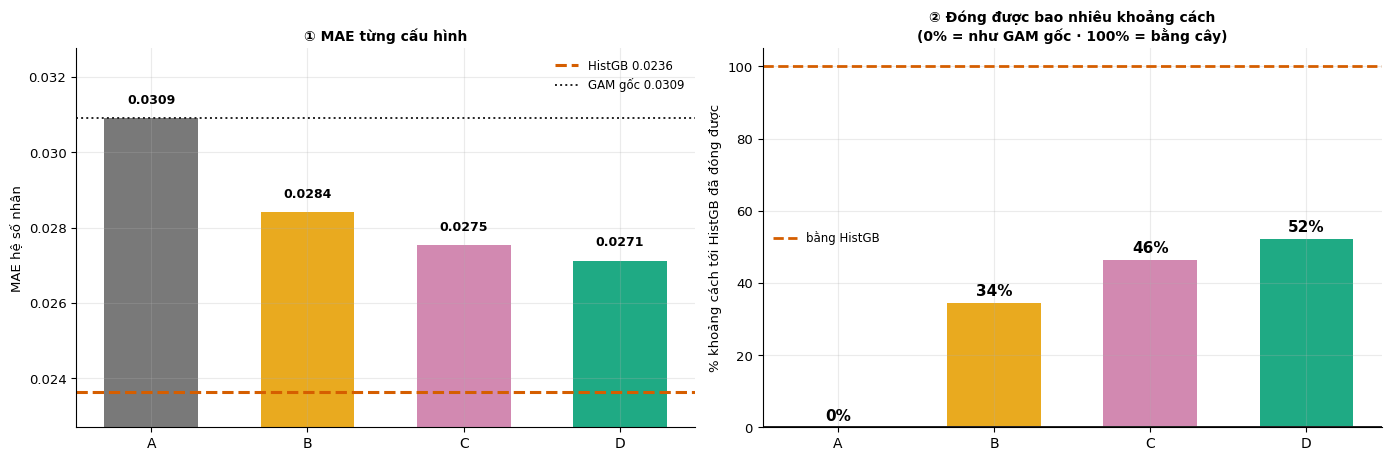

In [7]:
# ═════════ HINH TF2 — so sanh cau hinh ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.7))

ten4 = [r["ten"] for r in [A, B, C, D]]
mae4 = [r["mae"] for r in [A, B, C, D]]
mau4 = [MUT, ORANGE, PURPLE, GREEN]
b = ax[0].bar(range(4), mae4, color=mau4, alpha=.88, width=.6)
ax[0].axhline(mae_h, color=RED, lw=2.2, ls="--", label=f"HistGB {mae_h:.4f}")
ax[0].axhline(A["mae"], color=INK, lw=1.4, ls=":", label=f"GAM gốc {A['mae']:.4f}")
for bb, v in zip(b, mae4):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+.0004, f"{v:.4f}", ha="center",
               fontsize=9, fontweight="bold")
ax[0].set_xticks(range(4))
ax[0].set_xticklabels([t.split(".")[0] for t in ten4], fontsize=10)
ax[0].set_ylabel("MAE hệ số nhân")
ax[0].set_ylim(min(mae_h, min(mae4))*.96, max(mae4)*1.06)
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① MAE từng cấu hình", fontweight="bold", fontsize=10)

dong = [(1-(m-mae_h)/gap0)*100 for m in mae4]
b2 = ax[1].bar(range(4), dong, color=mau4, alpha=.88, width=.6)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].axhline(100, color=RED, lw=2, ls="--", label="bằng HistGB")
for bb, v in zip(b2, dong):
    ax[1].text(bb.get_x()+bb.get_width()/2, v + (2 if v >= 0 else -5),
               f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
ax[1].set_xticks(range(4))
ax[1].set_xticklabels([t.split(".")[0] for t in ten4], fontsize=10)
ax[1].set_ylabel("% khoảng cách tới HistGB đã đóng được")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Đóng được bao nhiêu khoảng cách\n(0% = như GAM gốc · 100% = bằng cây)",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "TF2_so_sanh_cau_hinh.png"); plt.show()

## 5. Mặt cong tương tác — thứ cây không cho xem

Đây là lý do đáng dùng `te()` thay vì bỏ sang cây: **vẫn nhìn thấy được** model học ra gì.

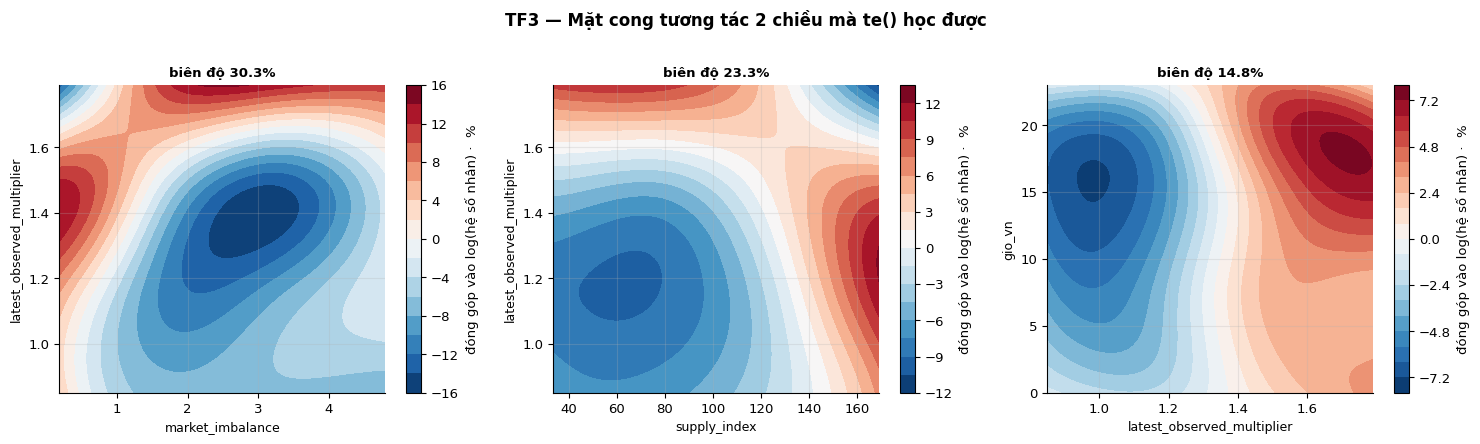

Neu mat cong KHONG phang va KHONG song song truc => co tuong tac that.


In [8]:
# ═════════ HINH TF3 — mat cong 2 chieu ═════════
n_base = len(M_NUM) + len(CAT)
fig, axes = plt.subplots(1, TOP_K, figsize=(5.0*TOP_K, 4.3))
axes = np.atleast_1d(axes)
for k, (a_, b_) in enumerate(cap_top):
    ax_ = axes[k]
    term_i = n_base + k
    XX = C["gam"].generate_X_grid(term=term_i, meshgrid=True)
    Z = C["gam"].partial_dependence(term=term_i, X=XX, meshgrid=True)
    x1, x2 = XX[0][:, :, 0] if XX[0].ndim == 3 else XX[0], XX[1]
    cs = ax_.contourf(XX[0], XX[1], Z*100, levels=18, cmap="RdBu_r")
    plt.colorbar(cs, ax=ax_, label="đóng góp vào log(hệ số nhân) ·  %")
    ax_.set_xlabel(a_.replace("pricing_", "").replace("_5m_lag", ""), fontsize=9)
    ax_.set_ylabel(b_.replace("pricing_", "").replace("_5m_lag", ""), fontsize=9)
    bd = (Z.max()-Z.min())*100
    ax_.set_title(f"biên độ {bd:.1f}%", fontsize=9.5, fontweight="bold")
fig.suptitle("TF3 — Mặt cong tương tác 2 chiều mà te() học được",
             fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "TF3_mat_cong_tuong_tac.png"); plt.show()
print("Neu mat cong KHONG phang va KHONG song song truc => co tuong tac that.")

## 6. Kết luận

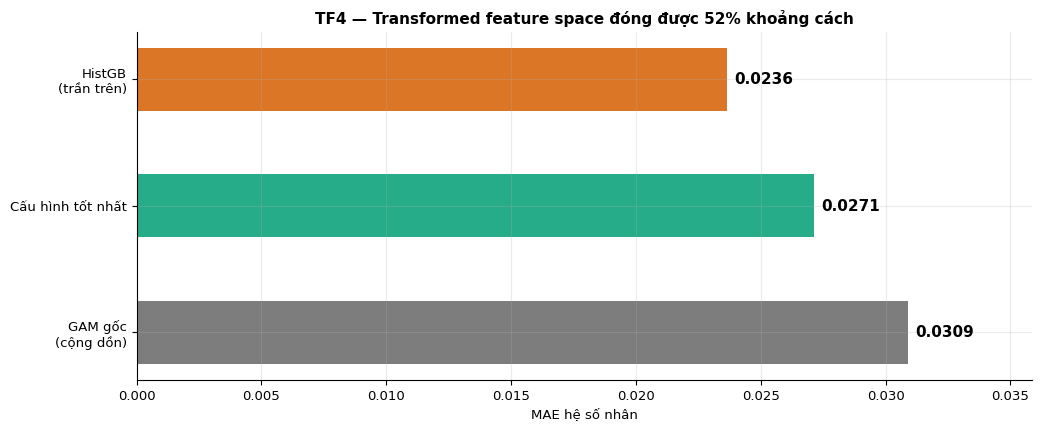

╔══════════════════════════════════════════════════════════════════════╗
║             GAM TREN TRANSFORMED FEATURE SPACE — KET QUA             ║
╚══════════════════════════════════════════════════════════════════════╝

  Khoang cach ban dau (GAM goc -> HistGB): 0.00726

  A. Cộng dồn thuần          MAE 0.03090  dong duoc     0% khoang cach
  B. + feature biến đổi      MAE 0.02840  dong duoc    34% khoang cach
  C. + tensor te() × 3       MAE 0.02753  dong duoc    46% khoang cach
  D. Gộp cả hai              MAE 0.02712  dong duoc    52% khoang cach
  HistGB (tran tren)         MAE 0.02364

────────────────────────────────────────────────────────────────────────
  => CAI THIEN VUA PHAI. D. Gộp cả hai dong duoc 52% khoang cach.
     Dang can nhac neu uu tien giai thich duoc hon do chinh xac.
────────────────────────────────────────────────────────────────────────


In [9]:
# ═════════ HINH TF4 — tong ket ═════════
fig, ax = plt.subplots(figsize=(10.5, 4.4))
tot = max(range(4), key=lambda i: -mae4[i])
ax.barh(["GAM gốc\n(cộng dồn)", "Cấu hình tốt nhất", "HistGB\n(trần trên)"],
        [A["mae"], mae4[tot], mae_h], color=[MUT, mau4[tot], RED], alpha=.85, height=.5)
for i, v in enumerate([A["mae"], mae4[tot], mae_h]):
    ax.text(v+.0003, i, f"{v:.4f}", va="center", fontsize=11, fontweight="bold")
ax.set_xlabel("MAE hệ số nhân")
ax.set_xlim(0, max(A["mae"], mae4[tot])*1.16)
ax.set_title(f"TF4 — Transformed feature space đóng được "
             f"{(1-(mae4[tot]-mae_h)/gap0)*100:.0f}% khoảng cách",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "TF4_tong_ket.png"); plt.show()

print("╔" + "═"*70 + "╗")
print("║" + " GAM TREN TRANSFORMED FEATURE SPACE — KET QUA ".center(70) + "║")
print("╚" + "═"*70 + "╝")
print()
print(f"  Khoang cach ban dau (GAM goc -> HistGB): {gap0:.5f}")
print()
for r, m in zip([A, B, C, D], mae4):
    print(f"  {r['ten']:26s} MAE {m:.5f}  dong duoc {(1-(m-mae_h)/gap0)*100:5.0f}% khoang cach")
print(f"  {'HistGB (tran tren)':26s} MAE {mae_h:.5f}")
print()
print("─" * 72)
tot_ten = ten4[tot]; dong_tot = (1-(mae4[tot]-mae_h)/gap0)*100
if dong_tot > 60:
    print(f"  => THANH CONG. {tot_ten} dong duoc {dong_tot:.0f}% khoang cach")
    print(f"     ma VAN GIU duoc tinh giai thich duoc (ve ra duoc mat cong).")
elif dong_tot > 25:
    print(f"  => CAI THIEN VUA PHAI. {tot_ten} dong duoc {dong_tot:.0f}% khoang cach.")
    print(f"     Dang can nhac neu uu tien giai thich duoc hon do chinh xac.")
else:
    print(f"  => KHONG DU. Chi dong duoc {dong_tot:.0f}% khoang cach.")
    print(f"     Tuong tac o he so nhan phuc tap hon 2 chieu -> giu boosting tree.")
print("─" * 72)

### Đọc kết quả

| Nếu đóng được | Kết luận |
|---|---|
| **> 60%** | Transformed feature space hiệu quả — dùng GAM cho nhánh hệ số nhân, được cả độ chính xác lẫn tính giải thích được |
| 25–60% | Cải thiện vừa phải — chọn theo ưu tiên: chính xác (cây) hay giải thích được (GAM) |
| **< 25%** | Tương tác phức tạp hơn 2 chiều — giữ boosting tree cho nhánh hệ số nhân |

### Vì sao chỉ làm cho **hệ số nhân**

Nhánh giá cơ bản GAM đã ngang cây (+0,5%) và phần dư gần như không còn cấu trúc (R² = 0,018) —
không có gì để đóng. Toàn bộ khoảng cách của GAM nằm ở nhánh hệ số nhân.

### ⚠️ Hạn chế

| Hạn chế | Ghi chú |
|---|---|
| Train trên **mẫu con** (`N_TRAIN`) | Số tuyệt đối khác model production; so sánh giữa cấu hình vẫn hợp lệ |
| Chỉ 1 tháng (`THANG_TRAIN`) | Model production train riêng cả 3 tháng |
| Chỉ thử tương tác **2 chiều** | Nếu tương tác thật là 3 chiều thì `te()` 2 chiều không đủ |
| `λ` cố định 0,6 | `train/04` đã cho thấy `λ` gần như không ảnh hưởng |
| Feature thủ công chọn theo lập luận kinh tế | Không quét toàn bộ không gian biến đổi |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `TF1_cuong_do_tuong_tac` | Bản đồ tương tác còn lại trong phần dư · top cặp |
| `TF2_so_sanh_cau_hinh` | MAE 4 cấu hình · % khoảng cách đóng được |
| `TF3_mat_cong_tuong_tac` | Mặt cong 2 chiều `te()` học được |
| `TF4_tong_ket` | GAM gốc vs tốt nhất vs trần trên |

## Liên quan

| File | Vai trò |
|---|---|
| `04_train_gam_doi_chieu.ipynb` | GAM production 3 nhánh — mốc so sánh |
| `../evaluation/08_truc_quan_GAM.ipynb` | Bằng chứng tương tác (phần dư R² = 0,562) |